# Historical Movers Analysis

This notebook analyzes historical Kraken data stored in PostgreSQL (TimescaleDB) to identify the most consistent high-volume movers. This analysis helps in selecting a stable universe of assets for backtesting and trading strategies.

In [1]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure project root is in path
project_root = os.path.abspath(os.path.join(os.getcwd(), "..", "src"))
if project_root not in sys.path:
    sys.path.append(project_root)

from ggTrader.data.historical.timescaledb_loader import TimescaleDBLoader

# Setup plotting style
sns.set_theme(style="whitegrid", palette="viridis")

In [2]:
# Initialize database reader
loader = TimescaleDBLoader()

# Calculate consistent movers over the last year
# This finds assets that appear most frequently in the daily top 50 by volume
movers_df = loader.get_consistent_movers(
    days=365,
    daily_top_n=50,
    output_n=50,
    trades_threshold=500,
    stables=False
)

print(f"Retrieved {len(movers_df)} consistent movers.")
movers_df.head(20)

Retrieved 50 consistent movers.


,symbol,frequency,average_notional_volume
0,BTC,318,1.615536e+08
1,ETH,318,9.471192e+07
2,XRP,318,6.201732e+07
3,SOL,318,4.663188e+07
4,DOGE,318,1.855936e+07
5,SUI,318,1.302417e+07
6,FARTCOIN,318,8.365675e+06
7,LINK,318,5.764978e+06
8,LTC,318,4.944985e+06
9,TAO,318,4.893996e+06


## Visualizing Top Movers

We analyze both the frequency (how often an asset is in the top 50) and the average notional volume.

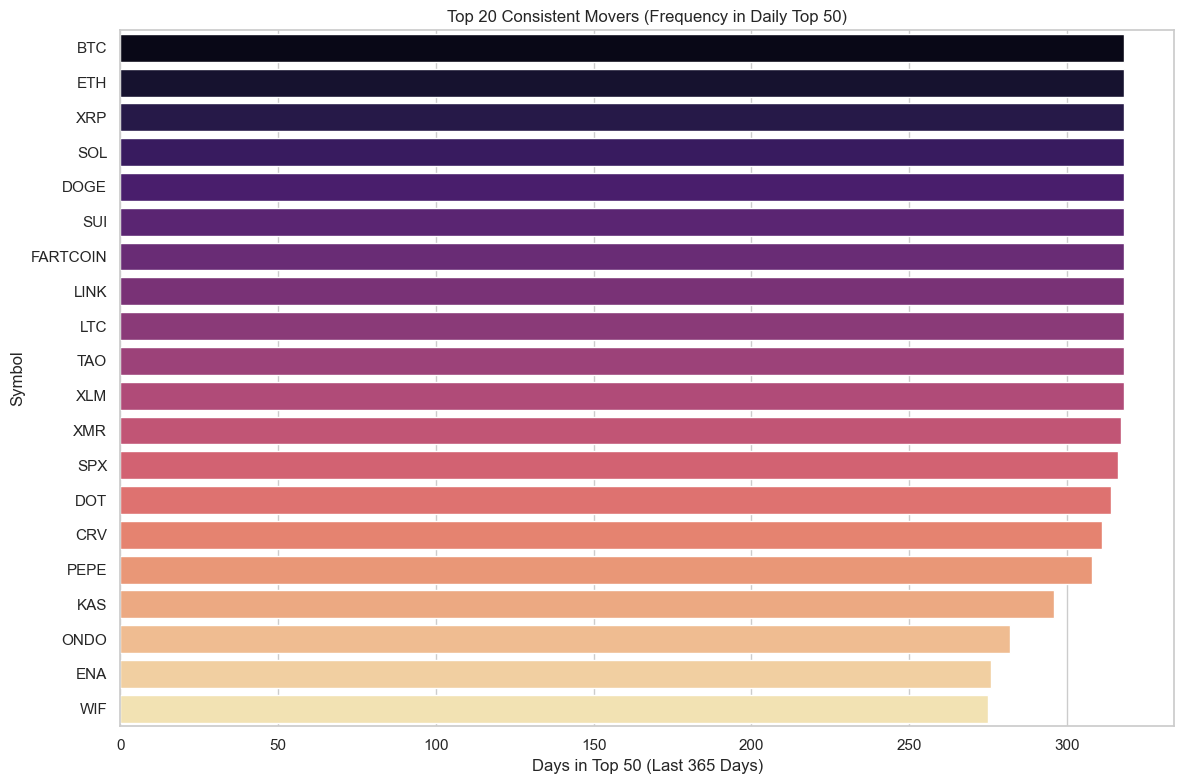

In [3]:
plt.figure(figsize=(12, 8))
sns.barplot(data=movers_df.head(20), x="frequency", y="symbol", hue="symbol", palette="magma", legend=False)
plt.title("Top 20 Consistent Movers (Frequency in Daily Top 50)")
plt.xlabel("Days in Top 50 (Last 365 Days)")
plt.ylabel("Symbol")
plt.tight_layout()
plt.show()

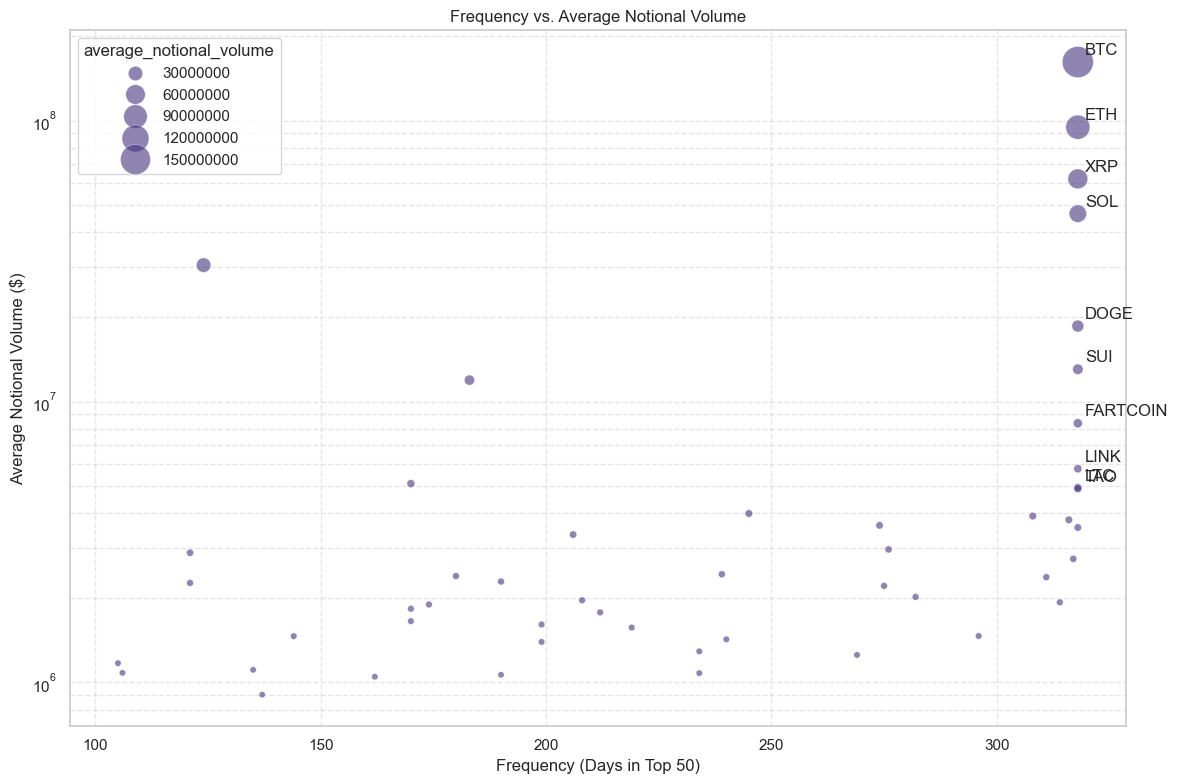

In [4]:
plt.figure(figsize=(12, 8))
sns.scatterplot(data=movers_df, x="frequency", y="average_notional_volume", size="average_notional_volume", sizes=(20, 500), alpha=0.6)
plt.title("Frequency vs. Average Notional Volume")
plt.xlabel("Frequency (Days in Top 50)")
plt.ylabel("Average Notional Volume ($)")
plt.yscale("log")
plt.grid(True, which="both", ls="--", alpha=0.5)

# Annotate top 10
for i in range(min(10, len(movers_df))):
    row = movers_df.iloc[i]
    plt.annotate(row["symbol"], (row["frequency"], row["average_notional_volume"]), xytext=(5, 5), textcoords="offset points")

plt.tight_layout()
plt.show()